In [3]:
# Step 0 : Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss, f1_score
from venn_abers import VennAbersCalibrator
import xgboost as xgb
import calibration as cal
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from scipy.io import arff
import warnings

warnings.filterwarnings("ignore")

In [11]:
# Step 1: Data Loading
print("Loading the dataset")

random_state = 28
# Really important and useful ###
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

data = arff.loadarff("../../data/dataset_stage_1.arff")  # TODO
df = pd.DataFrame(data[0])

df.head()  # TODO

Loading the dataset


,input_0,input_1,input_2,input_3,input_4,input_5,input_6,input_7,input_8,input_9,input_10,input_11,input_12,input_13,input_14,input_15,input_16,input_17,input_18,input_19,input_20,input_21,input_22,input_23,input_24,input_25,input_26,input_27,input_28,input_29,input_30,input_31,input_32,input_33,input_34,input_35,input_36,input_37,input_38,input_39,input_40,input_41,input_42,input_43,input_44,input_45,input_46,input_47,input_48,input_49,input_50,input_51,input_52,input_53,input_54,input_55,input_56,input_57,input_58,input_59,input_60,input_61,input_62,input_63,input_64,input_65,input_66,input_67,input_68,input_69,input_70,input_71,input_72,input_73,input_74,input_75,input_76,input_77,input_78,input_79,input_80,input_81,input_82,input_83,input_84,input_85,input_86,input_87,input_88,input_89,input_90,input_91,input_92,input_93,input_94,input_95,input_96,input_97,input_98,input_99,input_100,input_101,input_102,input_103,input_104,input_105,input_106,input_107,input_108,input_109,input_110,input_111,input_112,input_113,input_114,input_115,input_116,input_117,input_118,input_119,input_120,input_121,input_122,input_123,input_124,input_125,input_126,input_127,input_128,input_129,input_130,input_131,input_132,input_133,input_134,input_135,input_136,input_137,input_138,input_139,input_140,input_141,input_142,input_143,label
0,3.0,34.0,0.0,19.0,0.0,0.0,1.0,8.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,80.0,0.0,0.0,0.0
1,3.0,35.0,0.0,23.0,0.0,0.0,0.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,0.0,1.0,0.0
2,5.0,78.0,2.0,17.0,0.0,0.0,0.0,9.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0,0.0,2.0,0.0
3,1.0,32.0,0.0,9.0,0.0,0.0,0.0,9.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,0.0,3.0,0.0
4,9.0,79.0,1.0,17.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,

In [12]:
# Step 2 : Balancing the classes by oversampling
majority = df[df.label == df.label.value_counts().idxmax()]  # TODO
minority = df[df.label == df.label.value_counts().idxmin()]  # TODO
minority_upsampled = resample(  # TODO
    minority,  # TODO
    replace=True,
    n_samples=len(majority),  # TODO
    random_state=random_state,
)

df = pd.concat([majority, minority_upsampled])  # TODO
df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)  # TODO

print(df.head(10))

   input_0  input_1  input_2  input_3  input_4  input_5  input_6  input_7  \
0      4.0     65.0      0.0     18.0      0.0      0.0      0.0      5.0   
1     12.0     34.0      6.0     35.0      0.0      0.0      0.0      9.0   
2      2.0     26.0      2.0      4.0      3.0      1.0      0.0      5.0   
3      7.0     49.0      1.0     18.0      0.0      0.0      6.0      8.0   
4      1.0     38.0      1.0     12.0      0.0      0.0      2.0      9.0   
5      4.0     32.0      0.0      7.0      0.0      0.0      0.0      8.0   
6      8.0     53.0      1.0     24.0      0.0      0.0      0.0      9.0   
7      9.0     39.0      0.0     16.0      0.0      0.0      0.0      9.0   
8      2.0      1.0      1.0     12.0      0.0      1.0      3.0      5.0   
9      1.0     42.0      0.0     10.0      0.0      0.0      0.0      9.0   

   input_8  input_9  input_10  input_11  input_12  input_13  input_14  \
0      0.0      1.0       0.0       0.0       0.0       1.0       0.0   
1     

In [13]:
# Step 3 : Feature Preparation
X = df.drop(columns=["label"])  # TODO
y = df["label"].astype('int').values  # TODO
print(X.head(10))
print(pd.DataFrame(y, columns=["label"]).head(10))

   input_0  input_1  input_2  input_3  input_4  input_5  input_6  input_7  \
0      4.0     65.0      0.0     18.0      0.0      0.0      0.0      5.0   
1     12.0     34.0      6.0     35.0      0.0      0.0      0.0      9.0   
2      2.0     26.0      2.0      4.0      3.0      1.0      0.0      5.0   
3      7.0     49.0      1.0     18.0      0.0      0.0      6.0      8.0   
4      1.0     38.0      1.0     12.0      0.0      0.0      2.0      9.0   
5      4.0     32.0      0.0      7.0      0.0      0.0      0.0      8.0   
6      8.0     53.0      1.0     24.0      0.0      0.0      0.0      9.0   
7      9.0     39.0      0.0     16.0      0.0      0.0      0.0      9.0   
8      2.0      1.0      1.0     12.0      0.0      1.0      3.0      5.0   
9      1.0     42.0      0.0     10.0      0.0      0.0      0.0      9.0   

   input_8  input_9  input_10  input_11  input_12  input_13  input_14  \
0      0.0      1.0       0.0       0.0       0.0       1.0       0.0   
1     

In [ ]:
# Step 4 : Feature Scaling
scaler = StandardScaler()  # TODO
X = scaler.fit_transform(X)  # TODO # En general on le fait pas sur tout le dataset
print(pd.DataFrame(X).head(10))

        0         1         2         3         4         5         6    \
0 -0.182135  1.103848 -0.782809  0.199928 -0.306670 -0.227339 -0.546278   
1  2.486720 -0.488097  2.800775  2.296490 -0.306670 -0.227339 -0.546278   
2 -0.849349 -0.898921  0.411719 -1.526652  2.001194  0.620161 -0.546278   
3  0.818686  0.282199 -0.185545  0.199928 -0.306670 -0.227339  3.145511   
4 -1.182955 -0.282685 -0.185545 -0.540035 -0.306670 -0.227339  0.684318   
5 -0.182135 -0.590803 -0.782809 -1.156671 -0.306670 -0.227339 -0.546278   
6  1.152293  0.487611 -0.185545  0.939891 -0.306670 -0.227339 -0.546278   
7  1.485900 -0.231332 -0.782809 -0.046726 -0.306670 -0.227339 -0.546278   
8 -0.849349 -2.182747 -0.185545 -0.540035 -0.306670  0.620161  1.299616   
9 -1.182955 -0.077273 -0.782809 -0.786689 -0.306670 -0.227339 -0.546278   

        7         8         9         10        11        12        13   \
0 -1.349564 -0.077643  0.575037 -0.141961 -0.118352 -0.142169  1.081476   
1  0.784128 -0.077643  0

In [ ]:
# Step 5 : Data Splitting for Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,  # TODO
    y,  # TODO
    shuffle=True,  # TODO
    test_size=0.95,  # TODO
    random_state=random_state,
    stratify=y,  # TODO  Stratifying by the label
)
print(pd.DataFrame(X_train).head(5))
print(pd.Series(y_train).head(5))
print(pd.DataFrame(X_test).head(5))
print(pd.Series(y_test).head(5))

        0         1         2         3         4         5         6    \
0 -1.182955 -1.617864 -0.782809 -0.663362 -0.306670 -0.227339  0.069020   
1 -0.515742 -2.182747  1.008983 -1.033344 -0.306670 -0.227339 -0.546278   
2 -0.849349  0.436258 -0.185545 -0.786689  1.231906 -0.227339 -0.546278   
3 -0.849349 -0.744862  1.008983  0.446582 -0.306670 -0.227339 -0.546278   
4  0.151472  0.230846  0.411719  1.186545  4.309058 -0.227339  0.069020   

        7         8         9         10        11        12        13   \
0 -2.416410 -0.077643 -1.739018 -0.141961  8.449395 -0.142169 -0.924662   
1 -0.816141 -0.077643  0.575037 -0.141961 -0.118352 -0.142169 -0.924662   
2 -1.349564 -0.077643 -1.739018 -0.141961 -0.118352 -0.142169  1.081476   
3 -0.282718 -0.077643  0.575037 -0.141961 -0.118352 -0.142169  1.081476   
4  0.784128 -0.077643  0.575037 -0.141961 -0.118352 -0.142169 -0.924662   

        14        15        16        17        18        19        20   \
0 -0.004128 -0.117361  

In [ ]:
# Step 6 : Data Splitting for Proper Training and Calibration !!! Working on the training labels !!!
X_proper_train, X_cal, y_proper_train, y_cal = train_test_split(
    X_train,  # TODO
    y_train,  # TODO
    shuffle=True,  # TODO
    test_size=0.2,  # TODO
    random_state=random_state,
    stratify=y_train,  # TODO !stratifying by training label
)
print(pd.DataFrame(X_proper_train).head(5))
print(pd.Series(y_proper_train).head(5))
print(pd.DataFrame(X_cal).head(5))
print(pd.Series(y_cal).head(5))

        0         1         2         3         4         5         6    \
0  0.485079  0.333552 -0.782809 -0.910016 -0.306670 -0.227339 -0.546278   
1 -1.182955  0.590317 -0.782809 -1.773306 -0.306670 -0.227339  1.914915   
2  1.485900  0.333552  2.203511  0.816564 -0.306670 -0.227339 -0.546278   
3 -0.515742  0.795729 -0.782809 -1.279998  0.462618  1.467661  0.069020   
4  2.153113  0.538964 -0.782809  0.199928 -0.306670 -0.227339 -0.546278   

        7         8         9         10        11        12        13   \
0  0.784128 -0.077643  0.575037 -0.141961 -0.118352 -0.142169  1.081476   
1 -1.882987 -0.077643  0.575037 -0.141961 -0.118352 -0.142169  1.081476   
2 -0.816141 -0.077643  0.575037 -0.141961 -0.118352 -0.142169  1.081476   
3 -2.949833 -0.077643 -1.739018 -0.141961 -0.118352 -0.142169 -0.924662   
4  0.784128 -0.077643  0.575037 -0.141961 -0.118352 -0.142169 -0.924662   

        14        15        16        17        18        19        20   \
0 -0.004128 -0.117361  

In [20]:
# Step 7 : Model Definition
print("Models to test")
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=random_state,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=10,
        random_state=random_state,
    ),
    "XGBoost": xgb.XGBClassifier(
        tree_method="hist",
        random_state=random_state,
    ),
}
results = {}

for name_model in models.keys():
    print(f"- {name_model}")

Models to test
- Logistic Regression
- Random Forest
- XGBoost


In [24]:
# Step 8 : Example of model training
print("Example of model training and evaluation")
model_example = LogisticRegression(  # TODO
    max_iter = 5000,  # TODO
    random_state=random_state,  # TODO
)
model_example.fit(X_train, y_train)  # TODO
probs_example = model_example.predict_proba(X_test)[:, 1]  # TODO
preds_example = model_example.predict(X_test)  # TODO

print(probs_example[:5])
print(preds_example[:5])

Example of model training and evaluation
[0.66570806 0.3463777  0.2409     0.26778753 0.29137032]
[1 0 0 0 0]


In [ ]:
# Step 9 : Example of model evaluation
acc_example = f1_score(y_test, preds_example)  # TODO # here preds_example
brier_example = brier_score_loss(y_test, probs_example)  # TODO
logloss_example = log_loss(y_test, probs_example)  # TODO
ece_example = cal.get_calibration_error(probs_example, y_test)  # TODO # here reversed

print(f"Score Accuracy: {acc_example:.3f}")
print(f"Brier Score: {brier_example:.3f}")
print(f"Log Loss: {logloss_example:.3f}")
print(f"Expected Calibration Error: {ece_example:.3f}")

Score Accuracy: 0.588
Brier Score: 0.232
Log Loss: 0.663
Expected Calibration Error: 0.021


In [29]:
# Step 10 : Model Evaluation
for name, model in models.items():
    print(f"\n Entraînement du modèle : {name}")
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    acc = f1_score(y_test, model.predict(X_test))
    brier = brier_score_loss(y_test, probs)
    logloss = log_loss(y_test, probs)
    ece = cal.get_calibration_error(probs, y_test)
    print(f"Score Accuracy: {acc:.3f}")
    print(f"Brier Score: {brier:.3f}")
    print(f"Log Loss: {logloss:.3f}")
    print(f"Expected Calibration Error: {ece:.3f}")
    results[name] = {
        "model": model,
        "accuracy": acc,
        "probs": probs,
        "brier": brier,
        "logloss": logloss,
        "ece": ece,
    }


 Entraînement du modèle : Logistic Regression
Score Accuracy: 0.588
Brier Score: 0.232
Log Loss: 0.663
Expected Calibration Error: 0.021

 Entraînement du modèle : Random Forest
Score Accuracy: 0.634
Brier Score: 0.218
Log Loss: 0.722
Expected Calibration Error: 0.080

 Entraînement du modèle : XGBoost
Score Accuracy: 0.640
Brier Score: 0.226
Log Loss: 0.647
Expected Calibration Error: 0.057


In [31]:
# Step 11 : Example of model calibration : Sigmoid and Isotonic
model_example.fit(X_proper_train, y_proper_train)

for method in ["sigmoid", "isotonic"]:  # TODO
    print(f"\nCalibrating LogisticRegression with {method} method")
    # Wrap with CalibratedClassifierCV using the chosen method
    calibrated_model = CalibratedClassifierCV(
        estimator=model_example,  # TODO
        method=method,  # TODO
        cv="prefit",
    )
    calibrated_model.fit(X_cal, y_cal)  # TODO # working with cal here

    # Predict probabilities and classes on the test set
    probs_cal = calibrated_model.predict_proba(X_test)[:, 1]  # TODO
    preds_cal = calibrated_model.predict(X_test)  # TODO
    print(f"Probs calibration: {probs_cal[:5]}")
    print(f"Preds calibration: {preds_cal[:5]}")

    # Evaluate
    acc_cal = f1_score(y_test, preds_cal)  # TODO # Back to y_test here
    brier_cal = brier_score_loss(y_test, probs_cal)  # TODO
    logloss_cal = log_loss(y_test, probs_cal)  # TODO
    ece_cal = cal.get_calibration_error(probs_cal, y_test)  # TODO
    print(f"Score Accuracy: {acc_cal:.3f}")
    print(f"Brier Score: {brier_cal:.3f}")
    print(f"Log Loss: {logloss_cal:.3f}")
    print(f"Expected Calibration Error: {ece_cal:.3f}")


Calibrating LogisticRegression with sigmoid method
Probs calibration: [0.60927082 0.39640742 0.32562631 0.27792348 0.34835868]
Preds calibration: [1 0 0 0 0]
Score Accuracy: 0.589
Brier Score: 0.233
Log Loss: 0.663
Expected Calibration Error: 0.032

Calibrating LogisticRegression with isotonic method
Probs calibration: [0.66964286 0.40880503 0.21666667 0.21666667 0.38461538]
Preds calibration: [1 0 0 0 0]
Score Accuracy: 0.618
Brier Score: 0.234
Log Loss: 0.693
Expected Calibration Error: 0.055


In [ ]:
# Step 12 : Example of model calibration : Venn-ABERS (part 1 : calibration)
print("\nCalibrating LogisticRegression with Venn-ABERS method")
# Fit the model on the proper training set
model_example.fit(X_proper_train, y_proper_train)  # TODO
# Get predicted probabilities for calibration and test sets
p_cal = model_example.predict_proba(X_cal)  # TODO
p_test = model_example.predict_proba(X_test)  # TODO
# Calibrate and predict with VennAbersCalibrator
va = VennAbersCalibrator()
probs_va = va.predict_proba(p_cal=p_cal, y_cal=np.array(y_cal), p_test=p_test)[:, 1]  # TODO # why np.array here?
preds_va = va.predict(p_cal=p_cal, y_cal=np.array(y_cal), p_test=p_test)[:, 1]   # TODO
print(f"Probs calibration: {probs_va[:5]}")
print(f"Preds calibration: {preds_va[:5]}")


Calibrating LogisticRegression with Venn-ABERS method
Probs calibration: [0.66666667 0.409375   0.24110672 0.22580645 0.3898917 ]
Preds calibration: [1. 0. 0. 0. 0.]


In [33]:
# Step 13 : Example of model calibration : Venn-ABERS (part 2 : evaluation)
acc_va = f1_score(y_test, preds_va)  # TODO
brier_va = brier_score_loss(y_test, probs_va)  # TODO
logloss_va = log_loss(y_test, probs_va)  # TODO
ece_va = cal.get_calibration_error(probs_va, y_test)  # TODO
print(f"Score Accuracy: {acc_va:.3f}")
print(f"Brier Score: {brier_va:.3f}")
print(f"Log Loss: {logloss_va:.3f}")
print(f"Expected Calibration Error: {ece_va:.3f}")

Score Accuracy: 0.618
Brier Score: 0.234
Log Loss: 0.660
Expected Calibration Error: 0.046


In [34]:
# Step 14 : Model Calibration
def calibration():
    for name in models.keys():
        for method in ["sigmoid", "isotonic"]:
            print(f"\n Calibration de {name} avec méthode {method}")
            base_model = models[name].fit(X_proper_train, y_proper_train)
            calibrated_model = CalibratedClassifierCV(
                estimator=base_model, method=method, cv="prefit"
            )
            calibrated_model.fit(X_cal, y_cal)
            probs = calibrated_model.predict_proba(X_test)[:, 1]
            y_pred = calibrated_model.predict(X_test)
            acc = f1_score(y_test, y_pred)
            brier = brier_score_loss(y_test, probs)
            logloss = log_loss(y_test, probs)
            ece = cal.get_calibration_error(probs, y_test)
            print(f"Score Accuracy: {acc:.3f}")
            print(f"Brier Score: {brier:.3f}")
            print(f"Log Loss: {logloss:.3f}")
            print(f"Expected Calibration Error: {ece:.3f}")
            name_method = f"{name} + {method}"
            results[name_method] = {
                "probs": probs,
                "accuracy": acc,
                "brier": brier,
                "logloss": logloss,
                "ece": ece,
            }
        print(f"\n Calibration de {name} avec méthode Venn-ABERS")
        base_model = models[name].fit(X_proper_train, y_proper_train)
        p_cal = base_model.predict_proba(X_cal)
        p_test = base_model.predict_proba(X_test)
        va = VennAbersCalibrator()
        probs = va.predict_proba(p_cal=p_cal, y_cal=np.array(y_cal), p_test=p_test)[
            :, 1
        ]
        y_pred = va.predict(p_cal=p_cal, y_cal=np.array(y_cal), p_test=p_test)[:, 1]
        acc = f1_score(y_test, y_pred)
        brier = brier_score_loss(y_test, probs)
        logloss = log_loss(y_test, probs)
        ece = cal.get_calibration_error(probs, y_test)
        print(f"Score Accuracy: {acc:.3f}")
        print(f"Brier Score: {brier:.3f}")
        print(f"Log Loss: {logloss:.3f}")
        print(f"Expected Calibration Error: {ece:.3f}")
        name_method = f"{name} + Venn-ABERS"
        results[name_method] = {
            "probs": probs,
            "accuracy": acc,
            "brier": brier,
            "logloss": logloss,
            "ece": ece,
        }
    return


calibration()


 Calibration de Logistic Regression avec méthode sigmoid
Score Accuracy: 0.589
Brier Score: 0.233
Log Loss: 0.663
Expected Calibration Error: 0.032

 Calibration de Logistic Regression avec méthode isotonic
Score Accuracy: 0.618
Brier Score: 0.234
Log Loss: 0.693
Expected Calibration Error: 0.055

 Calibration de Logistic Regression avec méthode Venn-ABERS
Score Accuracy: 0.618
Brier Score: 0.234
Log Loss: 0.660
Expected Calibration Error: 0.046

 Calibration de Random Forest avec méthode sigmoid
Score Accuracy: 0.615
Brier Score: 0.222
Log Loss: 0.633
Expected Calibration Error: 0.055

 Calibration de Random Forest avec méthode isotonic
Score Accuracy: 0.615
Brier Score: 0.219
Log Loss: 0.626
Expected Calibration Error: 0.026

 Calibration de Random Forest avec méthode Venn-ABERS
Score Accuracy: 0.615
Brier Score: 0.219
Log Loss: 0.626
Expected Calibration Error: 0.024

 Calibration de XGBoost avec méthode sigmoid
Score Accuracy: 0.630
Brier Score: 0.227
Log Loss: 0.645
Expected Cali

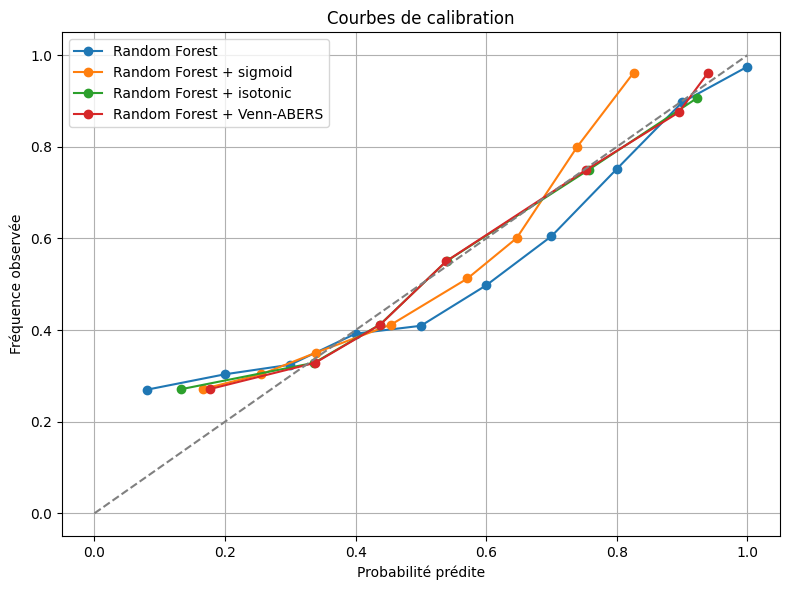

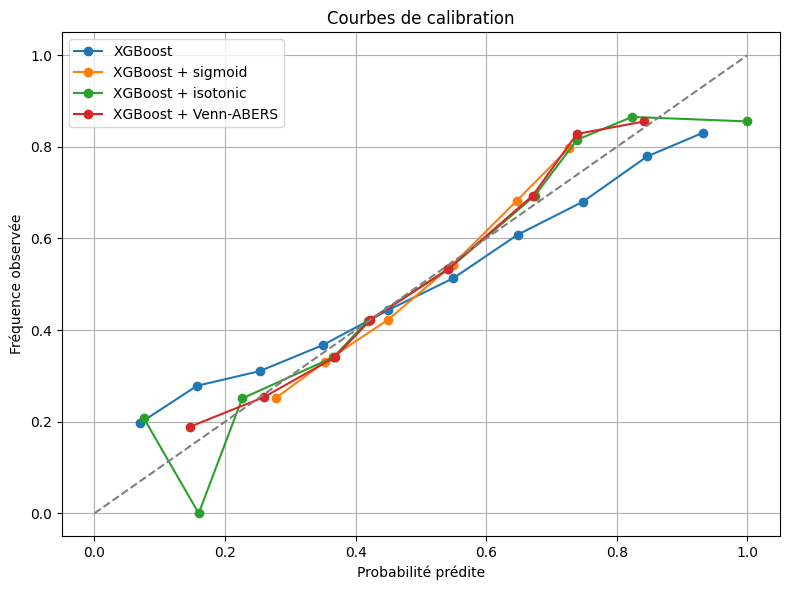

,Accuracy,Brier Score,Log Loss,ECE
Logistic Regression,0.588317,0.232006,0.663016,0.021078
Logistic Regression + Venn-ABERS,0.617602,0.233794,0.659858,0.046406
Logistic Regression + isotonic,0.617910,0.234010,0.692928,0.054709
Logistic Regression + sigmoid,0.588803,0.233404,0.662900,0.031731
Random Forest,0.634397,0.218455,0.721695,0.080278
Random Forest + Venn-ABERS,0.615201,0.219184,0.625545,0.024303
Random Forest + isotonic,0.615201,0.219252,0.625784,0.025655
Random Forest + sigmoid,0.615201,0.221572,0.632786,0.054769
XGBoost,0.640473,0.225787,0.647221,0.057460
XGBoost + Venn-ABERS,0.646002,0.226899,0.645486,0.038548


In [35]:
# Step 15: Plot Results
def plot():
    plt.figure(figsize=(8, 6))
    for name in [
        "Random Forest",
        "Random Forest + sigmoid",
        "Random Forest + isotonic",
        "Random Forest + Venn-ABERS",
    ]:
        res = results[name]
        prob_true, prob_pred = calibration_curve(y_test, res["probs"], n_bins=10)
        plt.plot(prob_pred, prob_true, marker="o", label=name)

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("Probabilité prédite")
    plt.ylabel("Fréquence observée")
    plt.title("Courbes de calibration")
    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    for name in [
        "XGBoost",
        "XGBoost + sigmoid",
        "XGBoost + isotonic",
        "XGBoost + Venn-ABERS",
    ]:
        res = results[name]
        prob_true, prob_pred = calibration_curve(y_test, res["probs"], n_bins=10)
        plt.plot(prob_pred, prob_true, marker="o", label=name)

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("Probabilité prédite")
    plt.ylabel("Fréquence observée")
    plt.title("Courbes de calibration")
    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    score_df = pd.DataFrame.from_dict(
        {
            name: {
                "Accuracy": res["accuracy"],
                "Brier Score": res["brier"],
                "Log Loss": res["logloss"],
                "ECE": res["ece"],
            }
            for name, res in results.items()
        },
        orient="index",
    ).sort_index()

    pd.set_option("display.max_rows", None)
    pd.set_option("display.width", 0)

    return score_df


plot()

In [36]:
# Step 16 : Run metrics function
def run_metrics(clf, X_test, y_test, results, probs=None, preds=None, va=False):
    if probs is None and preds is None:
        probs = clf.predict_proba(X_test)[:, 1]
        preds = clf.predict(X_test)
    if va:
        probs = clf.predict_proba(X_test)[:, 1]
        preds = clf.predict(X_test)[:, 1]
    acc = f1_score(y_test, preds)
    brier = brier_score_loss(y_test, probs)
    logloss = log_loss(y_test, probs)
    ece = cal.get_calibration_error(probs, y_test)
    results["accuracy"].append(acc)
    results["brier"].append(brier)
    results["log loss"].append(logloss)
    results["ece"].append(ece)
    return

In [ ]:
# Step 17 : Model Comparison !!! Not sure which argument to use for all of them betwen X_test_proper, X_test, and X_cal !!!
def compare_methods():
    # Prepare results storage
    metrics = ["accuracy", "brier", "log loss", "ece"]
    methods = [
        "Uncalibrated",
        "Isotonic",
        "Isotonic prefit",
        "Sigmoid",
        "Sigmoid prefit",
        "Prefit Venn-Abers",
        "IVAP",
        "CVAP",
    ]
    results = {m: [] for m in metrics}

    # Uncalibrated
    clf = GaussianNB()
    clf.fit(X_train, y_train)  # TODO
    run_metrics(clf, X_test, y_test, results)  # TODO

    # Isotonic (cv=5)
    iso = CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=5)  # TODO
    iso.fit(X_train, y_train)  # TODO
    run_metrics(iso, X_test, y_test, results)  # TODO

    # Isotonic prefit
    clf = GaussianNB()  # TODO
    clf.fit(X_proper_train, y_proper_train)  # TODO
    iso_prefit = CalibratedClassifierCV(clf, method="isotonic", cv="prefit")  # TODO
    iso_prefit.fit(X_train, y_train)  # TODO
    run_metrics(iso_prefit, X_test, y_test, results)  # TODO

    # Sigmoid (cv=5)
    sig = CalibratedClassifierCV(GaussianNB(), method="sigmoid", cv=5)  # TODO
    sig.fit(X_train, y_train)  # TODO
    run_metrics(sig, X_test, y_test, results)  # TODO

    # Sigmoid prefit
    clf = GaussianNB()
    clf.fit(X_proper_train, y_proper_train)  # TODO
    sig_prefit = CalibratedClassifierCV(clf, method="sigmoid", cv="prefit")  # TODO
    sig_prefit.fit(X_cal, y_cal)  # TODO # X_cal ??
    run_metrics(sig_prefit, X_test, y_test, results)  # TODO

    # Prefit
    clf = GaussianNB()  # TODO
    clf.fit(X_proper_train, y_proper_train)  # TODO
    p_cal = clf.predict_proba(X_cal)  # TODO  # On X_cal again
    p_test = clf.predict_proba(X_test)  # TODO
    va = VennAbersCalibrator()
    va_prefit_prob = va.predict_proba(
        p_cal=p_cal, y_cal=np.array(y_cal), p_test=p_test
    )[:, 1]
    y_pred = va.predict(p_cal=p_cal, y_cal=np.array(y_cal), p_test=p_test)[:, 1]
    run_metrics(va, X_test, y_test, results, probs=va_prefit_prob, preds=y_pred)  # TODO

    # IVAP
    va = VennAbersCalibrator(
        estimator=GaussianNB(),
        inductive=True,  # TODO
        cal_size=0.1,  # TODO # "leaving 20% of the training data??
        random_state=0,
    )
    va.fit(X_train, y_train)  # TODO
    run_metrics(va, X_test, y_test, results, va=True)  # TODO

    # CVAP
    va = VennAbersCalibrator(
        estimator=GaussianNB(),
        inductive=False,  # TODO
        n_splits=5,  # TODO
        random_state=0,
    )
    va.fit(X_train, y_train)  # TODO
    run_metrics(va, X_test, y_test, results, va=True)  # TODO

    print(
        "Summary of the results for the different calibration methods (base model: GaussianNB):"
    )
    df_loss = pd.DataFrame(results, index=methods).T.round(3)
    return df_loss


compare_methods()

Summary of the results for the different calibration methods (base model: GaussianNB):


,Uncalibrated,Isotonic,Isotonic prefit,Sigmoid,Sigmoid prefit,Prefit Venn-Abers,IVAP,CVAP
accuracy,0.663,0.588,0.649,0.661,0.662,0.654,0.652,0.647
brier,0.496,0.246,0.250,0.250,0.250,0.250,0.250,0.251
log loss,17.078,0.686,0.693,0.693,0.693,0.692,0.694,0.695
ece,0.489,0.079,0.028,0.161,0.096,0.013,0.029,0.044
